# Megabenchmark Analysis (RT Evaluation)

## Overview

This Jupyter Notebook performs an analytical evaluation of **Megabenchmark for Real-Time (RT)** test results.  

Megabenchmark consists of 4 tests in total: 
- Caterpillar with Cache Aligning Technology (CAT)
- Caterpillar without CAT
- Cyclictest with CAT
- Cyclictest witout CAT


---

## What is Caterpillar benchmark?

The Caterpillar benchmark measures how deterministically a system responds under load — specifically focusing on **timing jitter**, **CPU thermal conditions**, and **interrupt activity**.  

The **Caterpillar RT Benchmark** is a diagnostic tool designed to:
- Evaluate **real-time responsiveness** of CPU cores under varying system conditions.
- Measure **timing jitter** (variations in scheduling and latency).
- Identify hardware or kernel-level contributors to timing instability (e.g., IRQs, temperature fluctuations).

The benchmark runs multiple real-time workloads while collecting detailed monitoring data from the system.

---


## What is cyclictest benchmark?

---


## Input Data Description

The benchmark generates several monitoring files in the **output directory**, each containing time-synchronized measurements from different subsystems.

| File | Description |
|------|--------------|
| `output.csv` | Raw output file from benchmark run |
| `caterpillar_cat.csv` | Caterpillar results with CAT |
| `caterpillar_no_cat.csv` | Caterpillar results without CAT |
| `cyclictest_cat.csv` | Cyclictest results with CAT |
| `cyclictest_no_cat.csv` | Cyclictest results without CAT |
| `cpu_monitor.csv` | CPU temperature, frequency, and utilization per core. |
| `cpustat_monitor.csv` | Detailed CPU statistics (user/system/idle times, context switches). |
| `irq_monitor.csv` | IRQ activity counts per CPU core over time. |
| `softirq_monitor.csv` | Kernel-level soft interrupt counts per CPU core. |
| `meminfo_monitor.csv` | Memory pressure and allocation statistics. |
| `sysinfo.json` | System configuration and metadata (CPU topology, kernel version, etc.). |

---

## Structure of `caterpillar_cat.csv` and `caterpillar_no_cat.csv`

Caterpillar files contain per-sample jitter measurements recorded during the benchmark.  
Each row represents a single sampling point with both **sample-level** and **session-level** timing information.

| Column | Description | Units |
|---------|--------------|-------|
| `timestamp` | Timestamp of the measurement | ISO 8601 datetime |
| `SampleMin` | Minimum latency within current sampling window | microseconds (µs) |
| `SampleMax` | Maximum latency within current sampling window | microseconds (µs) |
| `SmplJitter` | Difference between `SampleMax` and `SampleMin` (per-sample jitter) | microseconds (µs) |
| `SessionMin` | Minimum latency observed since session start | microseconds (µs) |
| `SessionMax` | Maximum latency observed since session start | microseconds (µs) |
| `SessionJitter` | `SessionMax - SessionMin`, cumulative jitter for the session | microseconds (µs) |
| `Sample` | Sequential sample index | integer |


## Structure of `cyclictest_cat.csv` and `cyclictest_no_cat.csv`

| Short | Explanation                                                         |
|--------|----------------------------------------------------------------------|
| `timestamp` | Timestamp of the measurement                                     |
| `T`      | Thread: Thread index and thread ID                                  |
| `P`      | Priority: RT thread priority                                        |
| `I`      | Interval: Intended wake up period for the latency measuring threads |
| `C`      | Count: Number of times the latency was measured (iteration count)   |
| `Min`    | Minimum: Minimum latency that was measured                          |
| `Act`    | Actual: Latency measured during the latest completed iteration      |
| `Avg`    | Average: Average latency that was measured                          |
| `Max`    | Maximum: Maximum latency that was measured                          |


## How can I run analysis? 

You need to specify **folder** path in the next cell and run cells below, you will get report automatically then

In [1]:
megabench_data_path = "11-04-24"

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import sys
import os 
import yaml
import json
from datasets import load_dataset

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.plots import *

hf_dataset = "uncledecart/rtos"

output_csv_path = f"{megabench_data_path}/output.csv"
caterpillar_cat_path = f"{megabench_data_path}/caterpillar_cat.csv"
caterpillar_no_cat_path = f"{megabench_data_path}/caterpillar_no_cat.csv"
cyclictest_cat_path = f"{megabench_data_path}/cyclictest_cat.csv"
cyclictest_no_cat_path = f"{megabench_data_path}/cyclictest_no_cat.csv"
cpu_monitor_path = f"{megabench_data_path}/cpu_monitor.csv"
irq_monitor_path = f"{megabench_data_path}/irq_monitor.csv"
meminfo_path = f"{megabench_data_path}/meminfo_monitor.csv"
sysinfo_path = f"{megabench_data_path}/sysinfo.json"

### Sanity checks: 

Those checks are aimed to determine if the system is in a good shape to be analyzed, i.e. if there temperature is higher than a certain threshold, thermal throttling comes into play which would certainly affect Jitter and overal results

In [3]:
sysinfo = load_dataset(hf_dataset, data_files=sysinfo_path)['train']

sysinfo.json: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

In [4]:
sysinfo

Dataset({
    features: ['timestamp', 'os', 'kernel', 'cpu', 'memory', 'bios', 'power', 'pqos', 'interrupts', 'services', 'network', 'clock', 'irq_affinity', 'power_states', 'isolated_cpus', 'hydra'],
    num_rows: 1
})

In [6]:
assert sysinfo['hydra']['run']['command'][0] == 'mega-benchmark', "This notebook is designed to analyze cyclictest!"

In [7]:
print(f"""
Analyzing {sysinfo['hydra']['run']['command'][0]}
With isolated core(s): {sysinfo['hydra']['run']['t_core'][0]}
Cache mask: {sysinfo['hydra']['run']['llc_cache_mask'][0]}
System is stessed?: {sysinfo['hydra']['run']['stressor'][0]}
Kernel: {sysinfo['kernel']['uname'][0]}
Kernel CMD: {sysinfo['kernel']['cmdline'][0]}
""")


Analyzing mega-benchmark
With isolated core(s): 3
Cache mask: 0x000f
System is stessed?: True
Kernel: Linux zededa-rt 6.12.8-intel-ese-experimental-lts-rt #1 SMP PREEMPT_RT Thu, 28 Aug 2025 10:46:22 +0000 x86_64 GNU/Linux
Kernel CMD: BOOT_IMAGE=/vmlinuz-6.12.8-intel-ese-experimental-lts-rt root=/dev/mapper/zededa--rt--vg-root ro BOOT_IMAGE=/vmlinuz-6.12.8-intel-ese-experimental-lts-rt root=/dev/mapper/zededa--rt--vg-root ro debug=all nosplash console=ttyS0,115200 console=tty0 clocksource=tsc tsc=reliable art=virtallow no_ipi_broadcast=1 nosoftlockup efi=runtime numa_balancing=disable hugepages=1024 audit=0 nmi_watchdog=0 irqaffinity=0,1 mce=off hpet=disable rcupdate.rcu_cpu_stall_suppress=1 rcu_nocb_poll noht isolcpus=3,5,7,9 rcu_nocbs=3,5,7,9 nohz_full=3,5,7,9 intel_pstate=disable intel.max_cstate=0 intel_idle.max_cstate=0 processor.max_cstate=0 processor_idle.max_cstate=0 i915.force_probe=* i915.enable_rc6=0 i915.enable_dc=0 i915.disable_power_well=0 igb.blacklist=no



In [8]:
from typing import Sequence, Tuple
import re

def parse_kernel_cmdline(cmdline: str, params: Sequence[str]) -> dict[str, str]:
    results = {}

    for param in params:
        # Find all matches like param=value
        matches = re.findall(rf'\b{param}=([^ ]+)', cmdline)

        if not matches:
            print(f"{param}: not found")
            results[param] = None
        elif len(matches) == 1:
            print(f"{param}: {matches[0]}")
            results[param] = matches[0]
        else:
            print(f"WARNING: multiple occurrences of '{param}' found! Using latest value.")

            
            for value in matches:
                print(f"  -> {param}={value}")
            latest = matches[-1]
            print(f"Using latest: {param}={latest}")
            results[param] = latest

    return results

In [10]:
# check 1: selected for tests CPUs are isolated

params = parse_kernel_cmdline(str(sysinfo['kernel']['cmdline']), ["rcu_nocbs", "nohz_full", "isolcpus"])

for cpu in sysinfo['hydra']['run']['t_core'][0].split(','):
    for k, v in params.items():
        assert cpu in v, f"{k} parameter of kernel cmdline is missing CPU {cpu} which is used in tests"

rcu_nocbs: 3,5,7,9
nohz_full: 3,5,7,9
isolcpus: 3,5,7,9


In [12]:
# check 2 p-state and c-state are disabled

params = parse_kernel_cmdline(str(sysinfo['kernel']['cmdline']), ["intel_pstate", "intel.max_cstate", "intel_idle.max_cstate", "processor.max_cstate", "processor_idle.max_cstate"])

assert params["intel_pstate"] == "disable", "Intel p-state must be disabled"
assert params["intel.max_cstate"] == "0", "Intel c-state must be disabled"
assert params["intel_idle.max_cstate"] == "0", "Intel c-state must be disabled"
assert params["processor.max_cstate"] == "0", "Intel c-state must be disabled"
assert params["processor_idle.max_cstate"] == "0", "Intel c-state must be disabled"

intel_pstate: disable
intel.max_cstate: 0
intel_idle.max_cstate: 0
processor.max_cstate: 0
processor_idle.max_cstate: 0


In [15]:
# check 3: hypter-threading is disabled

assert " noht " in str(sysinfo['kernel']['cmdline'])

Generating train split: 0 examples [00:00, ? examples/s]

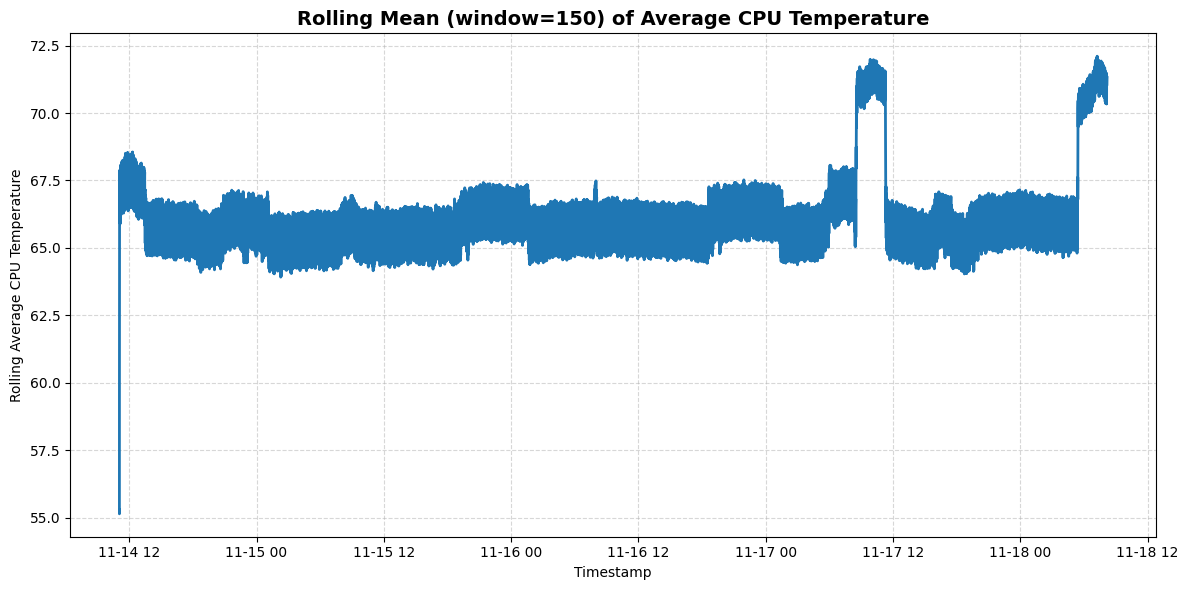

In [16]:
heat_threshold = 90
cpu_monitor_df = load_dataset("uncledecart/rtos", data_files=cpu_monitor_path)['train'].to_pandas()


### Check 1: Packages do not exceed threshold

packages = [col for col in cpu_monitor_df.columns if col.startswith("Package id")]

for pkg in packages:
    assert cpu_monitor_df[pkg].max() <= heat_threshold

### Check 2: CPUs do not exceed threshold

cpus = [col for col in cpu_monitor_df.columns if col.startswith("CPU")]

for cpu in cpus:
    assert cpu_monitor_df[cpu].max() <= heat_threshold

### Check 3: plot average temperature

plot_avg_cpu_temp(cpu_monitor_df)

In [1]:
irq_monitor_df = load_dataset("uncledecart/rtos", data_files=irq_monitor_path)['train'].to_pandas()
mask = irq_monitor_df['description'].str.contains('APIC|MSIX', case=False, regex=True, na=False)
global_irqs = irq_monitor_df[mask]

for cpu in sysinfo['hydra']['run']['t_core'][0].split(','):
    assert global_irqs[f'CPU{cpu}'].sum() == 0

## Bonus check: plot cumsum of CPU interrupts for each CPU

cpu_cols = [col for col in irq_monitor_df.columns if col.startswith('CPU')]
cpu_df = global_irqs[cpu_cols]
cpu_cumsum_df = cpu_df.cumsum()

cpu_long_df = cpu_cumsum_df.reset_index().melt(id_vars='index', var_name='CPU', value_name='Cumulative Value')

# Plot with seaborn
plt.figure(figsize=(12, 6))
sns.lineplot(data=cpu_long_df, x='index', y='Cumulative Value', hue='CPU', linewidth=2)

plt.title('Cumulative Sum of system interrruptions per CPU')
plt.xlabel('Sample Index')
plt.ylabel('Cumulative Value')
plt.legend(title='CPU', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

NameError: name 'load_dataset' is not defined

In [ ]:
meminfo_monitor_df = load_dataset("uncledecart/rtos", data_files=meminfo_path)['train'].to_pandas()
plot_meminfo(meminfo_monitor_df)

In [ ]:
caterpillar_cat = load_dataset("uncledecart/rtos", data_files=caterpillar_cat_path)['train'].to_pandas()
fit_and_plot_gev(caterpillar_cat, "SessionJitter")

In [ ]:
caterpillar_no_cat = load_dataset("uncledecart/rtos", data_files=caterpillar_no_cat_path)['train'].to_pandas()
fit_and_plot_gev(caterpillar_no_cat, "SessionJitter")

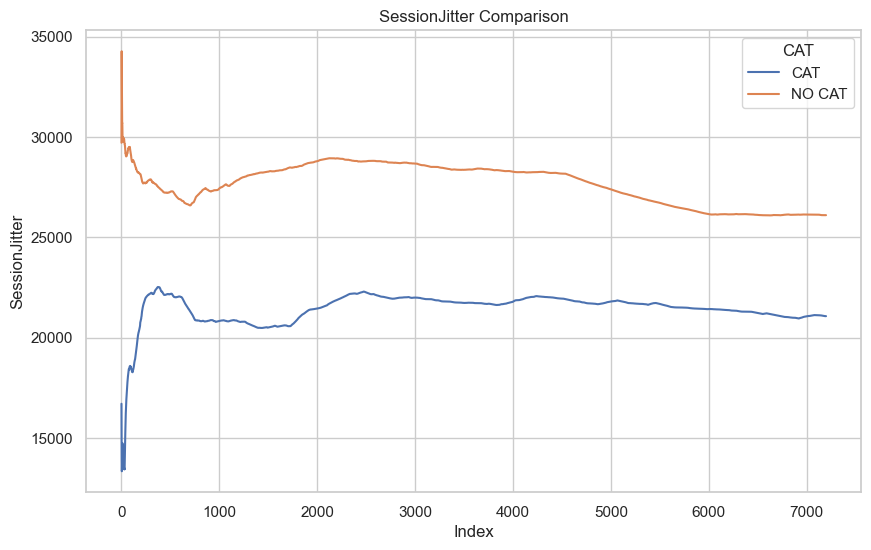

In [14]:
caterpillar_cat['Source'] = 'CAT'
caterpillar_no_cat['Source'] = 'NO CAT'


combined_df = pd.concat([caterpillar_cat[['SessionJitter', 'Source', 'Sample']], caterpillar_no_cat[['SessionJitter', 'Source', 'Sample']]], ignore_index=True)

plt.figure(figsize=(10, 6))
sns.lineplot(data=combined_df, x='Sample', y='SessionJitter', hue='Source')
plt.title('SessionJitter Comparison')
plt.xlabel('Index')
plt.ylabel('SessionJitter')
plt.legend(title='CAT')
plt.show()

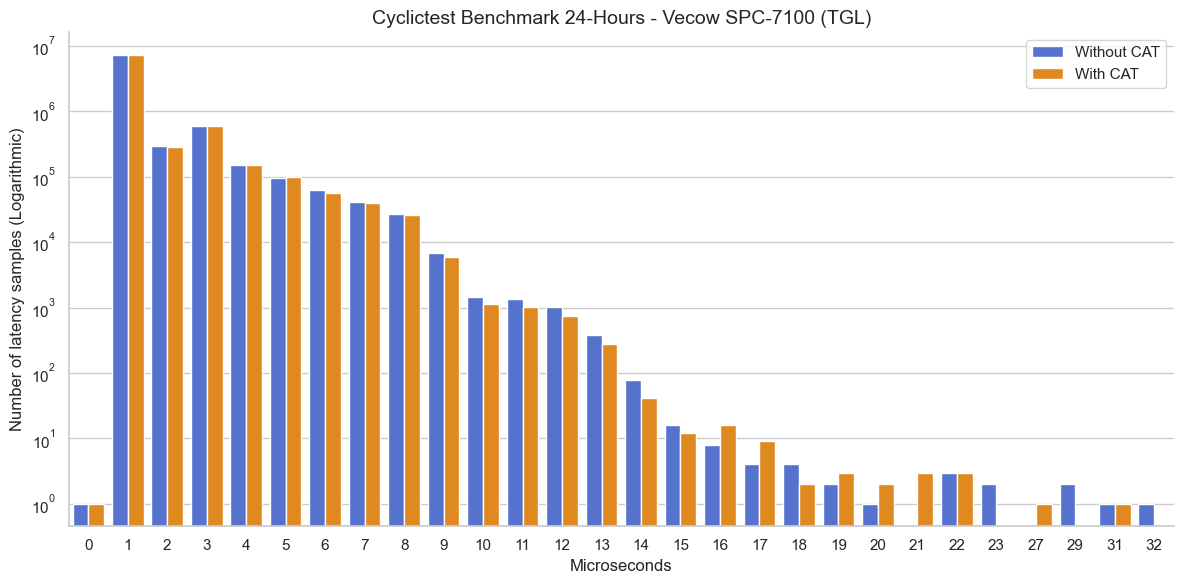

In [16]:
cyclictest_cat = load_dataset("uncledecart/rtos", data_files=cyclictest_cat_path)['train'].to_pandas()
cyclictest_no_cat = load_dataset("uncledecart/rtos", data_files=cyclictest_no_cat_path)['train'].to_pandas()


# Count occurrences of each microsecond value
count_no_cat = cyclictest_no_cat['Act'].value_counts().sort_index().reset_index()
count_no_cat.columns = ['Microseconds', 'Count']
count_no_cat['Mode'] = 'Without CAT'

count_cat = cyclictest_cat['Act'].value_counts().sort_index().reset_index()
count_cat.columns = ['Microseconds', 'Count']
count_cat['Mode'] = 'With CAT'

# Combine both datasets
combined = pd.concat([count_no_cat, count_cat])

# --- Plot ---
plt.figure(figsize=(12, 6))
sns.barplot(
    data=combined,
    x='Microseconds',
    y='Count',
    hue='Mode',
    palette=['royalblue', 'darkorange'],
    dodge=True
)

plt.yscale('log')
plt.title('Cyclictest Benchmark 24-Hours - Vecow SPC-7100 (TGL)', fontsize=14)
plt.xlabel('Microseconds')
plt.ylabel('Number of latency samples (Logarithmic)')
sns.despine()
plt.legend(title=None)
plt.tight_layout()
plt.show()

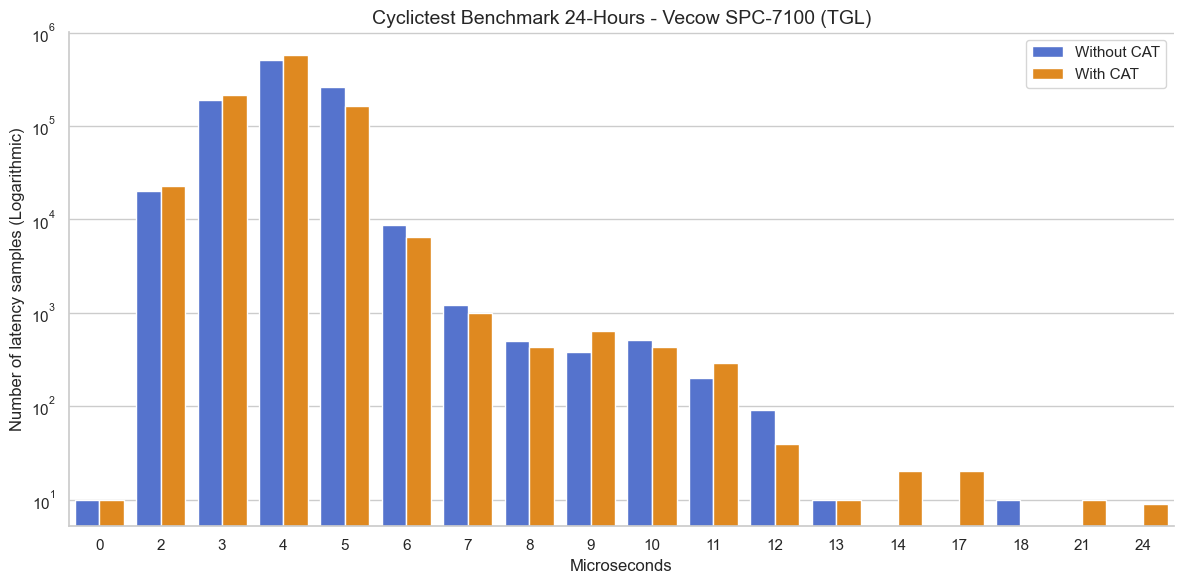

In [15]:
cyclictest_cat = pd.read_csv(cyclictest_cat_path) 
cyclictest_no_cat = pd.read_csv(cyclictest_no_cat_path) 

# Count occurrences of each microsecond value
count_no_cat = cyclictest_no_cat['Act'].value_counts().sort_index().reset_index()
count_no_cat.columns = ['Microseconds', 'Count']
count_no_cat['Mode'] = 'Without CAT'

count_cat = cyclictest_cat['Act'].value_counts().sort_index().reset_index()
count_cat.columns = ['Microseconds', 'Count']
count_cat['Mode'] = 'With CAT'

# Combine both datasets
combined = pd.concat([count_no_cat, count_cat])

# --- Plot ---
plt.figure(figsize=(12, 6))
sns.barplot(
    data=combined,
    x='Microseconds',
    y='Count',
    hue='Mode',
    palette=['royalblue', 'darkorange'],
    dodge=True
)

plt.yscale('log')
plt.title('Cyclictest Benchmark 24-Hours - Vecow SPC-7100 (TGL)', fontsize=14)
plt.xlabel('Microseconds')
plt.ylabel('Number of latency samples (Logarithmic)')
sns.despine()
plt.legend(title=None)
plt.tight_layout()
plt.show()

In [17]:
cyclictest_cat.tail(1)

,timestamp,T,T_ID,P,I,C,Min,Act,Avg,Max
8580783,2025-11-09 19:58:36,0,2748064,99,250,345599993,1,1,1,174


In [18]:
cyclictest_no_cat.tail(1)

,timestamp,T,T_ID,P,I,C,Min,Act,Avg,Max
8580752,2025-11-08 19:58:36,0,244113,99,250,345599989,1,1,1,52
